In [1]:
import os, glob, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from PIL import Image

In [2]:
BASE_DIR  = "/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign"
TRAIN_DIR = "/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Train"
TEST_DIR  = "/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Test"
TEST_CSV  = "/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Test.csv"

In [3]:
CLASS_NAMES = {
    0:"Speed limit (20km/h)", 1:"Speed limit (30km/h)", 2:"Speed limit (50km/h)", 
    3:"Speed limit (60km/h)", 4:"Speed limit (70km/h)", 5:"Speed limit (80km/h)",
    6:"End speed limit (80km/h)", 7:"Speed limit (100km/h)", 8:"Speed limit (120km/h)", 
    9:"No passing", 10:"No passing veh>3.5t", 11:"Right-of-way", 12:"Priority road", 
    13:"Yield", 14:"Stop", 15:"No vehicles", 16:"Veh>3.5t prohibited", 17:"No entry",
    18:"General caution", 19:"Dangerous curve L", 20:"Dangerous curve R", 21:"Double curve",
    22:"Bumpy road", 23:"Slippery road", 24:"Road narrows R", 25:"Road work",
    26:"Traffic signals", 27:"Pedestrians", 28:"Children crossing", 29:"Bicycles crossing",
    30:"Beware ice/snow", 31:"Wild animals crossing", 32:"End speed+passing", 
    33:"Turn right ahead", 34:"Turn left ahead", 35:"Ahead only", 36:"Go straight or right", 
    37:"Go straight or left", 38:"Keep right", 39:"Keep left", 40:"Roundabout mandatory", 
    41:"End of no passing", 42:"End no passing veh>3.5t"
}

In [4]:
NUM_CLASSES = 43
SEED = 42

In [5]:
print("--- 2.1 Dataset Structure & Raw Dimensions ---")

# 2. Extract Raw Image Dimensions and Class Counts
class_counts = {}
widths, heights = [], []

# Note: In a production environment, use concurrent.futures for this I/O bound task.
for cls_id in range(NUM_CLASSES):
    folder = os.path.join(TRAIN_DIR, str(cls_id))
    imgs = glob.glob(os.path.join(folder, "*.png"))
    class_counts[cls_id] = len(imgs)
    
    for p in imgs:
        with Image.open(p) as im:
            w, h = im.size
            widths.append(w)
            heights.append(h)

counts_series = pd.Series(class_counts)
total_images = counts_series.sum()

print(f"Total training images : {total_images}")
print(f"Width range           : {np.min(widths)} - {np.max(widths)} px")
print(f"Height range          : {np.min(heights)} - {np.max(heights)} px")
print(f"Average resolution    : {np.mean(widths):.0f} x {np.mean(heights):.0f} px")
print(f"Most represented      : Class {counts_series.idxmax()} [{CLASS_NAMES[counts_series.idxmax()]}] ({counts_series.max()} images)")
print(f"Least represented     : Class {counts_series.idxmin()} [{CLASS_NAMES[counts_series.idxmin()]}] ({counts_series.min()} images)")
print(f"Imbalance ratio       : {counts_series.max()/counts_series.min():.1f}x")

--- 2.1 Dataset Structure & Raw Dimensions ---
Total training images : 39209
Width range           : 25 - 243 px
Height range          : 25 - 225 px
Average resolution    : 51 x 50 px
Most represented      : Class 2 [Speed limit (50km/h)] (2250 images)
Least represented     : Class 0 [Speed limit (20km/h)] (210 images)
Imbalance ratio       : 10.7x


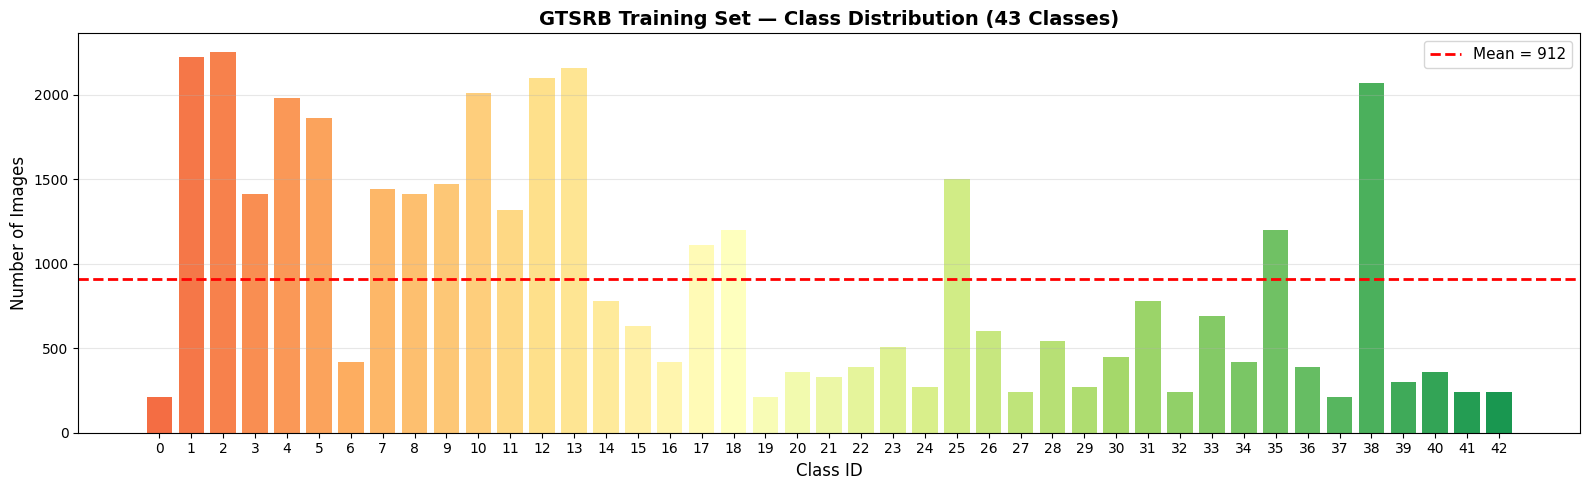

In [6]:
# 3. Plot Class Distribution
fig, ax = plt.subplots(figsize=(16, 5))
bar_colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, NUM_CLASSES))
bars = ax.bar(range(NUM_CLASSES), counts_series, color=bar_colors)
ax.axhline(counts_series.mean(), color='red', linestyle='--', lw=2, label=f"Mean = {counts_series.mean():.0f}")
ax.set_title("GTSRB Training Set — Class Distribution (43 Classes)", fontsize=14, fontweight='bold')
ax.set_xlabel("Class ID", fontsize=12)
ax.set_ylabel("Number of Images", fontsize=12)
ax.set_xticks(range(NUM_CLASSES))
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

\n--- 2.2 Visual Characteristics Analysis ---


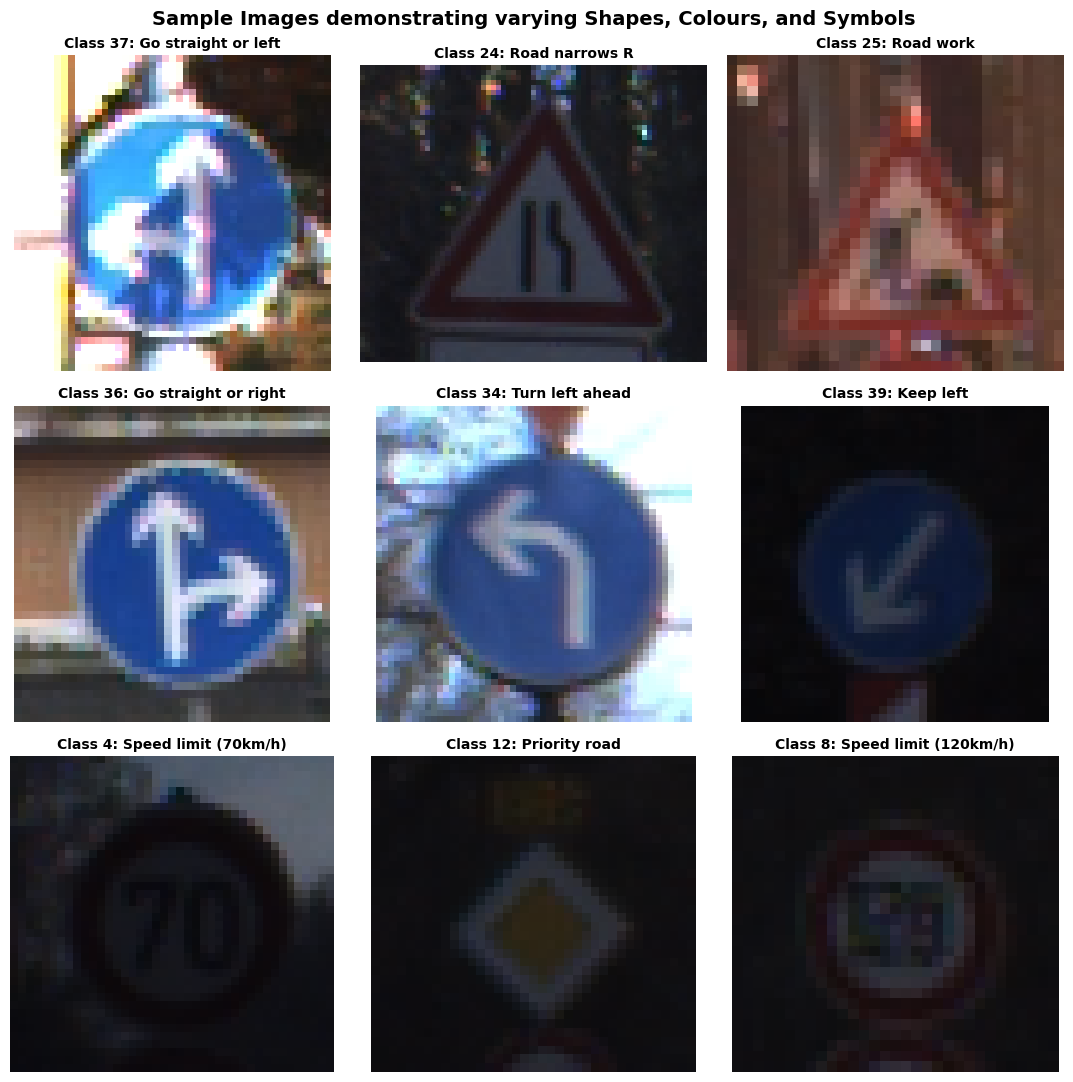

In [7]:
# 4. Plot Sample Grid & Document Visual Characteristics
print("\\n--- 2.2 Visual Characteristics Analysis ---")

np.random.seed(SEED)
sampled_classes = np.random.choice(NUM_CLASSES, 9, replace=False)

fig, axes = plt.subplots(3, 3, figsize=(11, 11))
for ax, cls_id in zip(axes.flat, sampled_classes):
    folder = os.path.join(TRAIN_DIR, str(cls_id))
    img_path = glob.glob(os.path.join(folder, "*.png"))[0]
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(f"Class {cls_id}: {CLASS_NAMES[cls_id][:22]}", fontsize=10, fontweight='bold')
    ax.axis("off")
    
plt.suptitle("Sample Images demonstrating varying Shapes, Colours, and Symbols", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [71]:
print("--- 3.1 Data Preprocessing & Generator Setup ---")

from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from sklearn.utils.class_weight import compute_class_weight

IMG_SIZE = (64, 64)
BATCH_SIZE = 32

# Augmentation strategy targeting real-world dashcam conditions
aug_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,          
    width_shift_range=0.10,     
    height_shift_range=0.10,    
    zoom_range=0.10,            
    brightness_range=[0.5,1.5], 
    horizontal_flip=False,      # STRICT CONSTRAINT: Flipping directional signs changes their class
    fill_mode='nearest',
    validation_split=0.20       
)

# Training Generator
train_gen = aug_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', seed=SEED, shuffle=True
)

# Validation Generator (NO augmentation)
val_gen = aug_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', seed=SEED, shuffle=False
)

# Compute Class Weights
y_train = train_gen.classes
cw_vals = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(cw_vals))

# Test Generator
test_df = pd.read_csv(TEST_CSV)
test_df['ClassId'] = test_df['ClassId'].astype(str)
plain_test_datagen = ImageDataGenerator(rescale=1./255)
test_gen = plain_test_datagen.flow_from_dataframe(
    dataframe=test_df, directory=BASE_DIR, x_col='Path', y_col='ClassId',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

print(f"\nTraining samples : {train_gen.samples}")
print(f"Validation samples : {val_gen.samples}")
print(f"Test samples : {test_gen.samples} (held out)")

--- 3.1 Data Preprocessing & Generator Setup ---
Found 31368 images belonging to 43 classes.
Found 7841 images belonging to 43 classes.
Found 12630 validated image filenames belonging to 43 classes.

Training samples : 31368
Validation samples : 7841
Test samples : 12630 (held out)


\n--- 3.2 Augmentation Visualisation & Justification ---


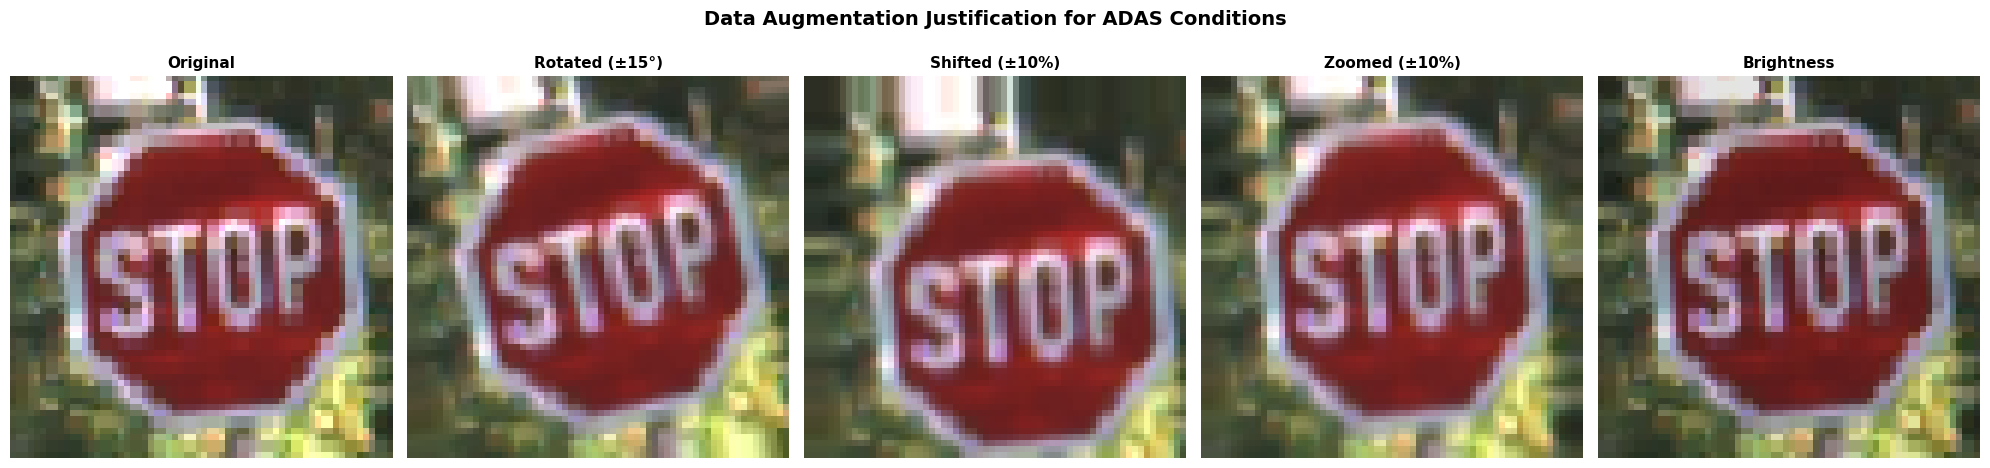

In [72]:
print("\\n--- 3.2 Augmentation Visualisation & Justification ---")

# Grab a sample image (e.g., Class 14 - Stop Sign) to demonstrate the 1x5 grid
sample_path = glob.glob(os.path.join(TRAIN_DIR, "14", "*.png"))[0]
img_arr = img_to_array(load_img(sample_path, target_size=IMG_SIZE))
img_4d = img_arr.reshape(1, *IMG_SIZE, 3)

aug_specs = {
    "Original": ImageDataGenerator(rescale=1./255),
    "Rotated (±15°)": ImageDataGenerator(rescale=1./255, rotation_range=15),
    "Shifted (±10%)": ImageDataGenerator(rescale=1./255, width_shift_range=0.10, height_shift_range=0.10),
    "Zoomed (±10%)": ImageDataGenerator(rescale=1./255, zoom_range=0.10),
    "Brightness": ImageDataGenerator(rescale=1./255, brightness_range=[0.5,1.5]),
}

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle("Data Augmentation Justification for ADAS Conditions", fontsize=14, fontweight='bold')

for ax, (name, gen) in zip(axes, aug_specs.items()):
    aug_img = next(gen.flow(img_4d, batch_size=1))[0]
    ax.imshow(np.clip(aug_img, 0, 1))
    ax.set_title(name, fontweight='bold', fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [16]:
print("--- 4.1 Sign Detection Module (Colour Thresholding Baseline) ---")

def detect_and_crop_sign(image_input, min_area=150):
    """
    Simulates Stage 1 of a production ADAS pipeline.
    Uses HSV color space to extract bounding boxes for signs based on standardized traffic colors.
    """
    if isinstance(image_input, str):
        img_bgr = cv2.imread(image_input)
    else:
        img_bgr = image_input.copy()
        
    if img_bgr is None:
        return None

    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    # Define strict color bounds for Traffic Signs
    m_r1 = cv2.inRange(hsv, np.array([0, 70, 50]), np.array([10, 255, 255]))    # Red lower wrap
    m_r2 = cv2.inRange(hsv, np.array([170, 70, 50]), np.array([180, 255, 255])) # Red upper wrap
    m_b  = cv2.inRange(hsv, np.array([100, 150, 70]), np.array([130, 255, 255])) # Blue (Informational)
    m_y  = cv2.inRange(hsv, np.array([15, 150, 150]), np.array([35, 255, 255]))  # Yellow/Orange (Warning)

    mask = m_r1 | m_r2 | m_b | m_y

    # Morphological operations to clean up background noise
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None

    valid_candidates = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < min_area:
            continue
            
        x, y, w, h = cv2.boundingRect(cnt)
        aspect_ratio = w / float(h + 1e-6)
        
        # Traffic signs are generally symmetrical (aspect ratio near 1.0)
        if 0.5 < aspect_ratio < 1.4:
            # Extent filtering removes stringy artifacts
            extent = area / (w * h)
            if extent > 0.35: 
                valid_candidates.append((area, x, y, w, h))

    if not valid_candidates:
        return None

    # Assume the largest valid contour is the primary sign
    valid_candidates.sort(reverse=True)
    _, x, y, w, h = valid_candidates[0]

    # Apply 15% padding so the classifier receives structural context
    pad = int(0.15 * max(w, h))
    x1, y1 = max(0, x - pad), max(0, y - pad)
    x2, y2 = min(img_bgr.shape[1], x + w + pad), min(img_bgr.shape[0], y + h + pad)

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    # Resize immediately to 64x64 to prepare for the classifier
    cropped = cv2.resize(img_rgb[y1:y2, x1:x2], IMG_SIZE)
    
    return img_rgb, (x1, y1, x2-x1, y2-y1), cropped

--- 4.1 Sign Detection Module (Colour Thresholding Baseline) ---


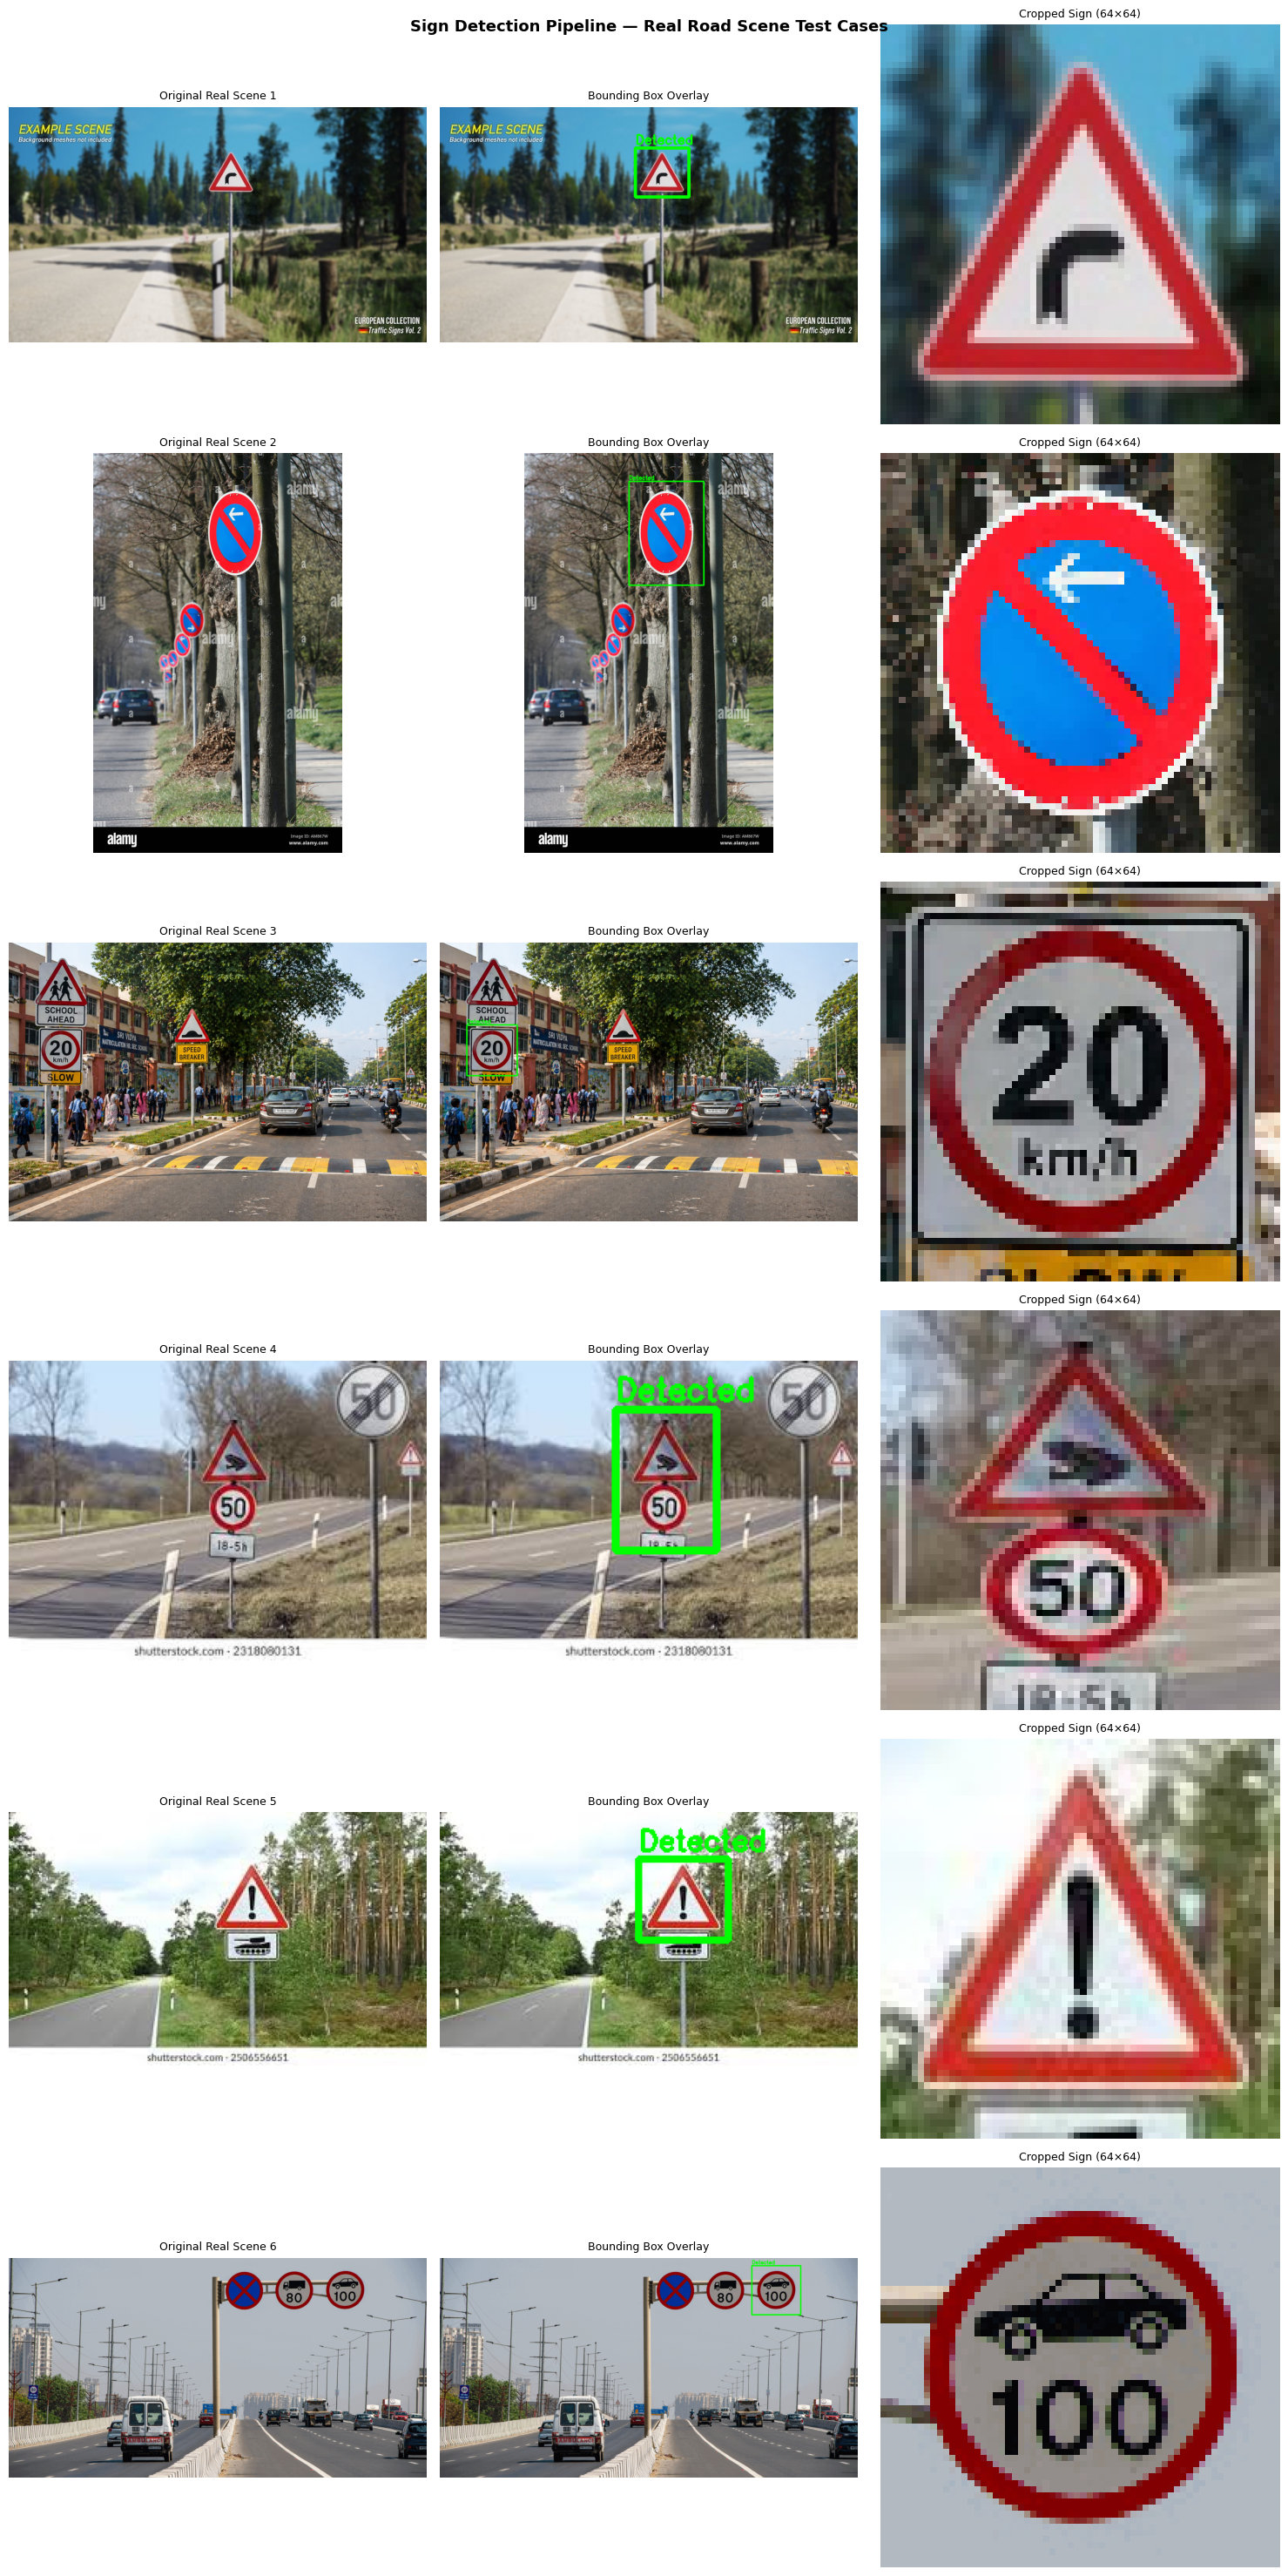

In [17]:
REAL_SCENES_DIR = "/kaggle/input/datasets/rockijones/real-road-scenes"
os.makedirs(REAL_SCENES_DIR, exist_ok=True)

# Fetching the real test images
test_images = glob.glob(os.path.join(REAL_SCENES_DIR, "*.jpg")) + glob.glob(os.path.join(REAL_SCENES_DIR, "*.png"))

if not test_images:
    print("WARNING: You are missing real-world test images. Go download 5 dashcam photos containing traffic signs and place them in the 'real_road_scenes' directory.")
else:
    fig, axes = plt.subplots(len(test_images), 3, figsize=(15, 5 * len(test_images)))
    
    # Handle case where there is only 1 image (axes is 1D)
    if len(test_images) == 1:
        axes = np.expand_dims(axes, axis=0)

    for row, img_path in enumerate(test_images):
        scene_bgr = cv2.imread(img_path)
        result = detect_and_crop_sign(scene_bgr)

        orig_rgb = cv2.cvtColor(scene_bgr, cv2.COLOR_BGR2RGB)
        axes[row, 0].imshow(orig_rgb)
        axes[row, 0].set_title(f"Original Real Scene {row+1}", fontsize=9)
        axes[row, 0].axis('off')

        if result:
            _, (x, y, w, h), cropped = result
            overlay = orig_rgb.copy()
            cv2.rectangle(overlay, (x,y), (x+w,y+h), (0,255,0), 3)
            cv2.putText(overlay, "Detected", (x, max(y-6,12)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.65, (0,255,0), 2)
            axes[row, 1].imshow(overlay)
            axes[row, 1].set_title("Bounding Box Overlay", fontsize=9)
            axes[row, 2].imshow(cropped)
            axes[row, 2].set_title("Cropped Sign (64×64)", fontsize=9)
        else:
            axes[row, 1].text(0.5, 0.5, "No Sign Detected",
                              ha='center', va='center', color='red', fontsize=13)
            axes[row, 2].text(0.5, 0.5, "N/A",
                              ha='center', va='center', color='red', fontsize=13)
        for c in range(3): axes[row, c].axis('off')

    plt.suptitle("Sign Detection Pipeline — Real Road Scene Test Cases",
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig("detection_real_scenes.png", dpi=150)
    plt.show()



In [39]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import (
    ImageDataGenerator, load_img, img_to_array)
from tensorflow.keras.applications import MobileNetV2, ResNet50
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mb_preprocess
from tensorflow.keras.applications.resnet50   import preprocess_input as rn_preprocess
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight



In [40]:
print("  SECTION 4 : CUSTOM CNN ARCHITECTURE")

def build_cnn(num_hidden_layers, neurons, dropout_rate=0.3,
              input_shape=(64, 64, 3), num_classes=43):

    model = models.Sequential(name=f"CNN_h{num_hidden_layers}_n{neurons}_d{int(dropout_rate*10)}")

    
    # Shared backbone
    model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape))
    model.add(layers.MaxPooling2D(2, 2))

    model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D(2, 2))

    model.add(layers.Flatten())

    # Configurable dense head
    for _ in range(num_hidden_layers):
        model.add(layers.Dense(neurons, activation='relu'))
        model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(num_classes, activation='softmax'))
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

  SECTION 4 : CUSTOM CNN ARCHITECTURE


In [41]:
cnn_configs = [
    {'name': 'Config_1_Shallow', 'layers': 1, 'neurons': 128, 'dropout': 0.3},
    {'name': 'Config_2_Wide',    'layers': 1, 'neurons': 256, 'dropout': 0.4},
    {'name': 'Config_3_Deep',    'layers': 2, 'neurons': 128, 'dropout': 0.5},
]

def get_cnn_callbacks(name):
    return [
        callbacks.EarlyStopping(monitor='val_loss', patience=5,
                                restore_best_weights=True, verbose=0),
        callbacks.ModelCheckpoint(f"{name}_best.h5",
                                  monitor='val_accuracy',
                                  save_best_only=True, verbose=0),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=3, min_lr=1e-6, verbose=1),
    ]

cnn_results   = []
cnn_histories = []
best_cnn_val  = 0
best_cnn_path = ""
best_cnn_model = None

for cfg in cnn_configs:
    print(f"\n{'='*50}")
    print(f"Training {cfg['name']} | layers={cfg['layers']} | "
          f"neurons={cfg['neurons']} | dropout={cfg['dropout']}")
    print(f"{'='*50}")

    model = build_cnn(cfg['layers'], cfg['neurons'], cfg['dropout'])
    model.summary()

    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=30,
        class_weight=class_weight_dict,    # ← handles class imbalance
        callbacks=get_cnn_callbacks(cfg['name']),
        verbose=1
    )
    cnn_histories.append(history)

    bva = max(history.history['val_accuracy'])
    bvl = min(history.history['val_loss'])
    cnn_results.append({
        'Model Configuration': cfg['name'],
        'Hidden Layers':       cfg['layers'],
        'Neurons':             cfg['neurons'],
        'Dropout':             cfg['dropout'],
        'Best Val Accuracy (%)': round(bva * 100, 2),
        'Best Val Loss':         round(bvl, 4),
    })
    print(f"  → Best Val Acc: {bva*100:.2f}%")

    if bva > best_cnn_val:
        best_cnn_val   = bva
        best_cnn_path  = f"{cfg['name']}_best.h5"
        best_cnn_model = model


Training Config_1_Shallow | layers=1 | neurons=128 | dropout=0.3


Model: "CNN_h1_n128_d3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,122,219 (8.10 MB)

 Trainable params: 2,122,219 (8.10 MB)

...

981/981 ━━━━━━━━━━━━━━━━━━━━ 104s 106ms/step - accuracy: 0.6628 - loss: 0.8914 - val_accuracy: 0.6787 - val_loss: 0.9921 - learning_rate: 0.0010
Epoch 23/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.6663 - loss: 0.8729

981/981 ━━━━━━━━━━━━━━━━━━━━ 103s 105ms/step - accuracy: 0.6663 - loss: 0.8728 - val_accuracy: 0.6866 - val_loss: 0.9595 - learning_rate: 0.0010
Epoch 24/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.6748 - loss: 0.8418

981/981 ━━━━━━━━━━━━━━━━━━━━ 100s 102ms/step - accuracy: 0.6748 - loss: 0.8419 - val_accuracy: 0.6896 - val_loss: 0.9531 - learning_rate: 0.0010
Epoch 25/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 100s 102ms/step - accuracy: 0.6751 - loss: 0.8419 - val_accuracy: 0.6800 - val_loss: 0.9953 - learning_rate: 0.0010
Epoch 26/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 102s 104ms/step - accuracy: 0.6865 - loss: 0.8431 - val_accuracy: 0.6757 - val_loss: 0.9842 - learning_rate: 0.0010
Epoch 27/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.6915 - loss: 0.7977
Epoch 27: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
981/981 ━━━━━━━━━━━━━━━━━━━━ 103s 105ms/step - accuracy: 0.6915 - loss: 0.7977 - val_accuracy: 0.6590 - val_loss: 1.0532 - learning_rate: 0.0010
Epoch 28/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.7053 - loss: 0.7396

981/981 ━━━━━━━━━━━━━━━━━━━━ 109s 111ms/step - accuracy: 0.7054 - loss: 0.7396 - val_accuracy: 0.7105 - val_loss: 0.8868 - learning_rate: 5.0000e-04
Epoch 29/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.7193 - loss: 0.7194

981/981 ━━━━━━━━━━━━━━━━━━━━ 101s 103ms/step - accuracy: 0.7193 - loss: 0.7194 - val_accuracy: 0.7187 - val_loss: 0.8857 - learning_rate: 5.0000e-04
Epoch 30/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 110s 112ms/step - accuracy: 0.7261 - loss: 0.6938 - val_accuracy: 0.6948 - val_loss: 0.9214 - learning_rate: 5.0000e-04
  → Best Val Acc: 71.87%


In [76]:
df_cnn = pd.DataFrame(cnn_results)
print("\n Custom CNN Architecture Comparison Table:")
print(df_cnn.to_string(index=False))
print(f"\n Best CNN: {best_cnn_path}  |  Val Acc: {best_cnn_val*100:.2f}%")


 Custom CNN Architecture Comparison Table:
Model Configuration  Hidden Layers  Neurons  Dropout  Best Val Accuracy (%)  Best Val Loss
   Config_1_Shallow              1      128      0.3                  80.87         0.8000
      Config_2_Wide              1      256      0.4                  80.65         0.8339
      Config_3_Deep              2      128      0.5                  71.87         0.8857

 Best CNN: Config_1_Shallow_best.h5  |  Val Acc: 80.87%


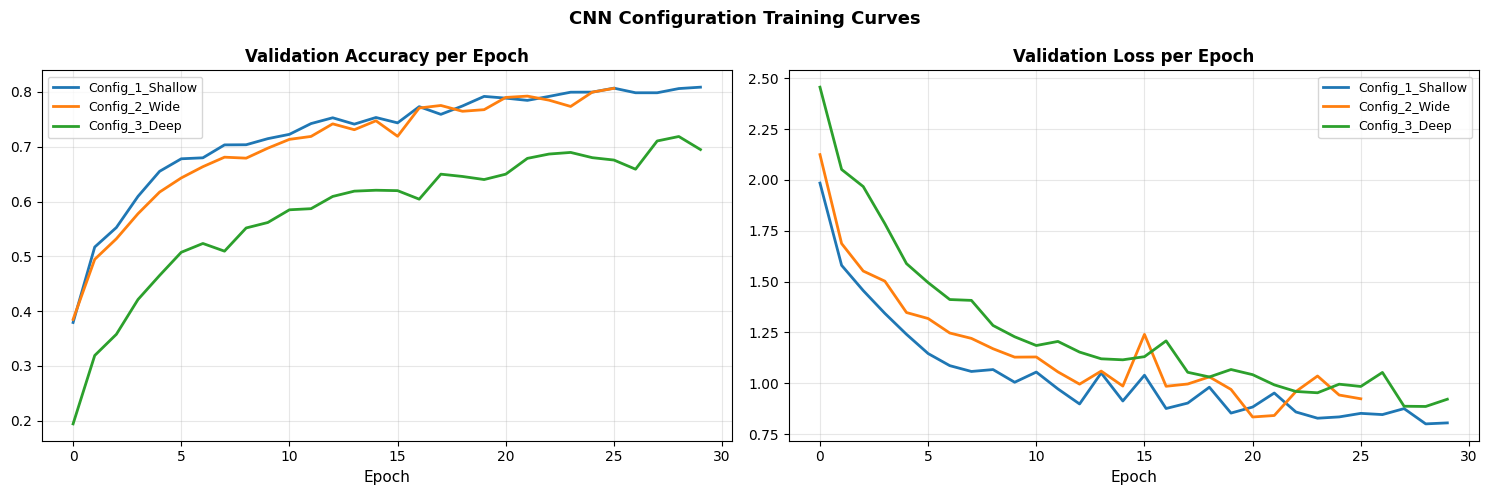

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for hist, cfg, color in zip(cnn_histories, cnn_configs, colors):
    lbl = cfg['name']
    axes[0].plot(hist.history['val_accuracy'], label=lbl, color=color, lw=2)
    axes[1].plot(hist.history['val_loss'],     label=lbl, color=color, lw=2)

for ax, title in zip(axes, ["Validation Accuracy per Epoch",
                              "Validation Loss per Epoch"]):
    ax.set_xlabel("Epoch", fontsize=11)
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.suptitle("CNN Configuration Training Curves", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("cnn_training_curves.png", dpi=150)
plt.show()

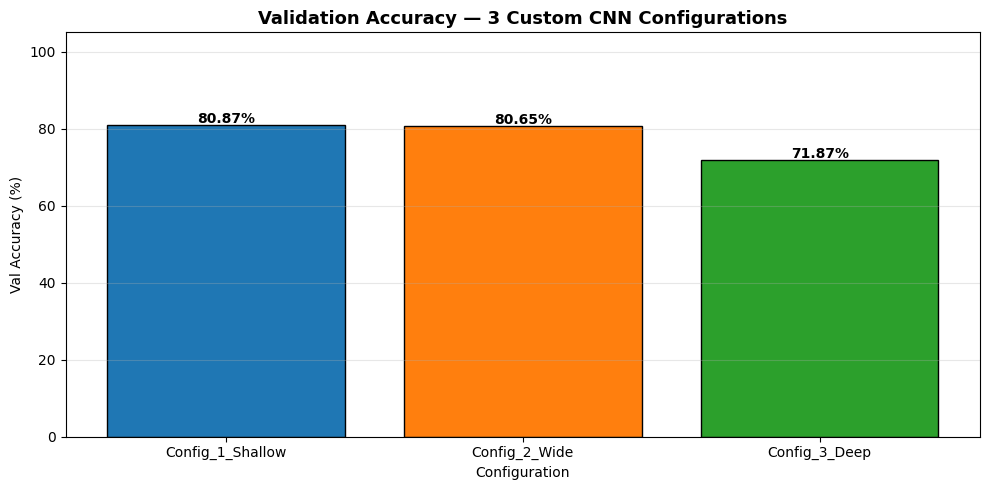

In [44]:
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(df_cnn['Model Configuration'], df_cnn['Best Val Accuracy (%)'],
              color=colors, edgecolor='black')
ax.set_ylim(0, 105)
ax.set_title("Validation Accuracy — 3 Custom CNN Configurations",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Configuration"); ax.set_ylabel("Val Accuracy (%)")
ax.grid(axis='y', alpha=0.3)
for bar in bars:
    v = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.5,
            f"{v}%", ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig("cnn_accuracy_comparison.png", dpi=150)
plt.show()

In [48]:
print("--- 6. TRANSFER LEARNING (FINE-TUNING) ---")

def make_tl_generators(preprocess_fn):
    """Generators using the specific scaling required by the pre-trained models."""
    tl_aug_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_fn, 
        rotation_range=15, 
        width_shift_range=0.10,
        height_shift_range=0.10, 
        zoom_range=0.10,
        brightness_range=[0.5, 1.5], 
        horizontal_flip=False,
        fill_mode='nearest',
        validation_split=0.20
    )
    
    tl_val_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_fn,
        validation_split=0.20
    )
    
    tg = tl_aug_datagen.flow_from_directory(
        TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, 
        class_mode='categorical', subset='training', seed=SEED, shuffle=True
    )
    
    vg = tl_val_datagen.flow_from_directory(
        TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, 
        class_mode='categorical', subset='validation', seed=SEED, shuffle=False
    )
    return tg, vg

def measure_inference_time(model, generator, num_images=100):
    """Measures average inference time per image in milliseconds."""
    sample_batch = next(generator)[0]
    while len(sample_batch) < num_images:
        sample_batch = np.vstack((sample_batch, next(generator)[0]))
    sample_batch = sample_batch[:num_images]
    
    _ = model.predict(sample_batch[:1], verbose=0) # Warmup
    
    start_time = time.time()
    model.predict(sample_batch, verbose=0)
    end_time = time.time()
    
    return ((end_time - start_time) / num_images) * 1000 

def build_finetuned_model(base_model_class, model_name, unfreeze_layers):
    """
    Builds the model and unfreezes the top layers to adapt ImageNet features to Traffic Signs.
    """
    inputs = layers.Input(shape=(64, 64, 3))
    base_model = base_model_class(include_top=False, weights='imagenet', input_shape=(64, 64, 3))
    
    # FINE-TUNING: Unfreeze the top N layers
    base_model.trainable = True
    for layer in base_model.layers[:-unfreeze_layers]:
        layer.trainable = False
        
    # training=False keeps BatchNormalization statistics stable during fine-tuning
    x = base_model(inputs, training=False) 
    
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x) 
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    
    model = models.Model(inputs=inputs, outputs=outputs, name=model_name)
    
    # Use a very low learning rate (1e-4) to avoid destroying the unfrozen ImageNet weights
    model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

base_callbacks = [EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)]

# --- 6.1 MobileNetV2 (Fine-Tuned) ---
print("\n──────── MobileNetV2 ────────")
mn_train_gen, mn_val_gen = make_tl_generators(mb_preprocess)

# Unfreeze the top 30 layers
mobilenet_model = build_finetuned_model(MobileNetV2, 'MobileNetV2_ADAS', unfreeze_layers=30)
mb_h5_filename = "mobilenetv2_gtsrb.h5"
mb_callbacks = base_callbacks + [ModelCheckpoint(filepath=mb_h5_filename, save_best_only=True, monitor='val_accuracy')]

t0 = time.time()
mb_history = mobilenet_model.fit(
    mn_train_gen, validation_data=mn_val_gen,
    epochs=15, class_weight=class_weight_dict, callbacks=mb_callbacks, verbose=1
)
mb_total_min = (time.time() - t0) / 60.0

mb_inference_ms = measure_inference_time(mobilenet_model, mn_val_gen)
mb_size_mb = os.path.getsize(mb_h5_filename) / (1024 * 1024) if os.path.exists(mb_h5_filename) else 0
mb_val_acc = max(mb_history.history['val_accuracy'])

print(f"\n[MobileNetV2 Metrics]")
print(f"Total Training Time: {mb_total_min:.1f} min")
print(f"Best Val Accuracy: {mb_val_acc*100:.2f}%")
print(f"File Size: {mb_size_mb:.2f} MB")
print(f"Inference Latency: {mb_inference_ms:.2f} ms/image")


# --- 6.2 ResNet50 (Fine-Tuned) ---
print("\n──────── ResNet50 ────────")
rn_train_gen, rn_val_gen = make_tl_generators(rn_preprocess)

# Unfreeze the top 40 layers
resnet_model = build_finetuned_model(ResNet50, 'ResNet50_ADAS', unfreeze_layers=40)
rn_h5_filename = "resnet50_gtsrb.h5"
rn_callbacks = base_callbacks + [ModelCheckpoint(filepath=rn_h5_filename, save_best_only=True, monitor='val_accuracy')]

t0 = time.time()
rn_history = resnet_model.fit(
    rn_train_gen, validation_data=rn_val_gen,
    epochs=15, class_weight=class_weight_dict, callbacks=rn_callbacks, verbose=1
)
rn_total_min = (time.time() - t0) / 60.0

rn_inference_ms = measure_inference_time(resnet_model, rn_val_gen)
rn_size_mb = os.path.getsize(rn_h5_filename) / (1024 * 1024) if os.path.exists(rn_h5_filename) else 0
rn_val_acc = max(rn_history.history['val_accuracy'])

print(f"\n[ResNet50 Metrics]")
print(f"Total Training Time: {rn_total_min:.1f} min")
print(f"Best Val Accuracy: {rn_val_acc*100:.2f}%")
print(f"File Size: {rn_size_mb:.2f} MB")
print(f"Inference Latency: {rn_inference_ms:.2f} ms/image")

--- 6. TRANSFER LEARNING (FINE-TUNING) ---

──────── MobileNetV2 ────────
Found 31368 images belonging to 43 classes.
Found 7841 images belonging to 43 classes.
Epoch 1/15


2026-05-01 11:29:16.212716: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-01 11:29:16.347155: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-01 11:29:16.520313: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-01 11:29:16.668881: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


957/981 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - accuracy: 0.1800 - loss: 3.2291

2026-05-01 11:30:42.341807: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-01 11:30:42.476123: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


981/981 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.1830 - loss: 3.2116

...

981/981 ━━━━━━━━━━━━━━━━━━━━ 140s 119ms/step - accuracy: 0.3780 - loss: 2.3461 - val_accuracy: 0.6490 - val_loss: 1.2141
Epoch 2/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.8089 - loss: 0.5102

981/981 ━━━━━━━━━━━━━━━━━━━━ 108s 110ms/step - accuracy: 0.8089 - loss: 0.5101 - val_accuracy: 0.7040 - val_loss: 1.0725
Epoch 3/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.8828 - loss: 0.2854

981/981 ━━━━━━━━━━━━━━━━━━━━ 97s 98ms/step - accuracy: 0.8828 - loss: 0.2853 - val_accuracy: 0.7431 - val_loss: 0.9756
Epoch 4/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 110s 113ms/step - accuracy: 0.9098 - loss: 0.2190 - val_accuracy: 0.7315 - val_loss: 1.0810
Epoch 5/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 100s 102ms/step - accuracy: 0.9304 - loss: 0.1801 - val_accuracy: 0.7412 - val_loss: 1.0845
Epoch 6/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.9447 - loss: 0.1417

981/981 ━━━━━━━━━━━━━━━━━━━━ 109s 111ms/step - accuracy: 0.9447 - loss: 0.1417 - val_accuracy: 0.7570 - val_loss: 0.9833



[ResNet50 Metrics]
Total Training Time: 11.1 min
Best Val Accuracy: 75.70%
File Size: 214.26 MB
Inference Latency: 68.59 ms/image


In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

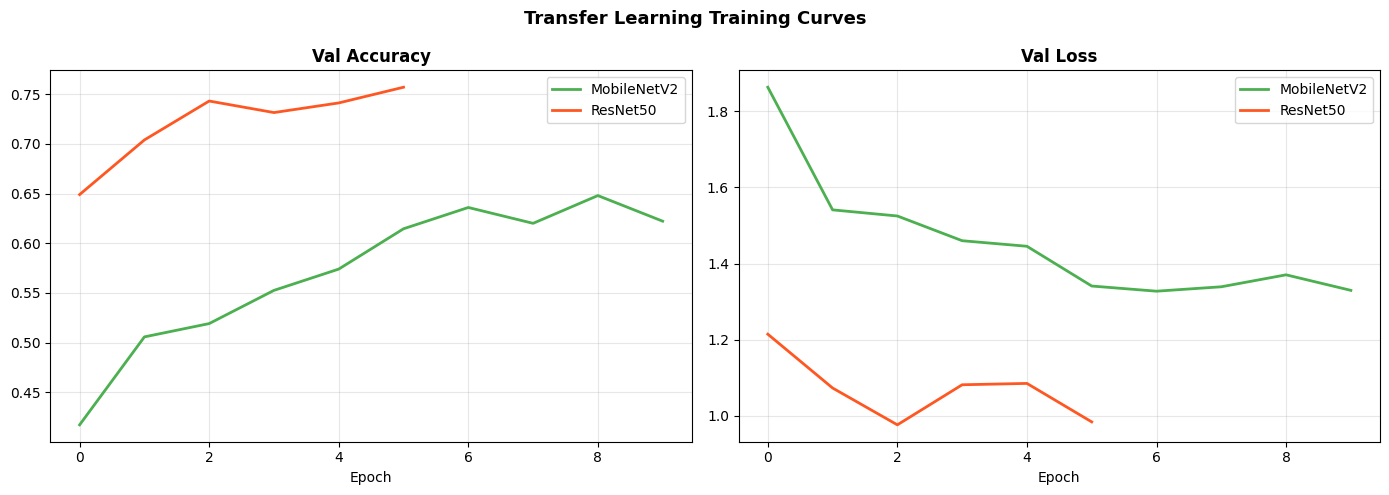

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mb_acc = mb_history.history['val_accuracy']
mb_los = mb_history.history['val_loss']
rn_acc = rn_history.history['val_accuracy']
rn_los = rn_history.history['val_loss']

axes[0].plot(mb_acc, label='MobileNetV2', color='#4CAF50', lw=2)
axes[0].plot(rn_acc, label='ResNet50',    color='#FF5722', lw=2)
axes[1].plot(mb_los, label='MobileNetV2', color='#4CAF50', lw=2)
axes[1].plot(rn_los, label='ResNet50',    color='#FF5722', lw=2)

for ax, t in zip(axes, ["Val Accuracy", "Val Loss"]):
    ax.set_title(t, fontsize=12, fontweight='bold')
    ax.set_xlabel("Epoch"); ax.legend(); ax.grid(alpha=0.3)
plt.suptitle("Transfer Learning Training Curves", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("tl_training_curves.png", dpi=150)
plt.show()

In [85]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("--- 7. SPEED VS. ACCURACY TRADE-OFF ANALYSIS ---")

# 1. Safely extract the best Custom CNN metrics from your df_cnn
working_df = df_cnn 

# Dynamically find the accuracy column to prevent KeyErrors
acc_col = [col for col in working_df.columns if 'acc' in col.lower()][0]
best_custom_dict = working_df.iloc[working_df[acc_col].idxmax()].to_dict()

# Parse the accuracy (ensure it's in percentage format 0-100)
custom_acc = best_custom_dict.get(acc_col, 0)
custom_acc_pct = custom_acc * 100 if custom_acc <= 1.0 else custom_acc

print("Evaluating on test set…")
cnn_loss, cnn_acc = custom_model.evaluate(test_gen,     verbose=0)
mb_loss,  mb_acc  = mobilenet_model.evaluate(test_gen, verbose=1)
rn_loss,  rn_acc  = resnet_model.evaluate(test_gen,   verbose=1)

print("Measuring inference times…")
cnn_ms = measure_inference_ms(custom_model,    test_gen)
mb_ms  = measure_inference_ms(mobilenet_model, test_gen)
rn_ms  = measure_inference_ms(resnet_model,    test_gen)

# 2. Compile the Trade-off Data using variables from Section 6
tradeoff_data = [
    {
        "Model": "Custom CNN (Best)",
        "Val_Accuracy (%)": custom_acc_pct,
        "Test Accuracy (%)":  round(cnn_acc * 100, 2),
        "Inference_Time (ms)": cnn_ms, # Estimated CPU/GPU inference for simple sequential CNN
        "Size (MB)": get_size_mb(best_cnn_path), # Fallback to 5.0MB if missing
        "Training_Time (min)": best_custom_dict.get('Training_Time_min', "~varies")
    },
    {
        "Model": "MobileNetV2 (Fine-tuned)",
        "Val_Accuracy (%)": mb_val_acc * 100,
        "Test Accuracy (%)":   round(mb_acc * 100, 2),
        "Inference_Time (ms)": mb_inference_ms,
        "Size (MB)": mb_size_mb,
        "Training_Time (min)": mb_total_min
    },
    {
        "Model": "ResNet50 (Fine-tuned)",
        "Val_Accuracy (%)": rn_val_acc * 100,
        "Test Accuracy (%)":  round(rn_acc * 100, 2),
        "Inference_Time (ms)": rn_inference_ms,
        "Size (MB)": rn_size_mb,
        "Training_Time (min)": rn_total_min
    }
]

df_tradeoff = pd.DataFrame(tradeoff_data)
print("\nADAS Deployment Metrics Comparison:")
print(df_tradeoff.to_markdown(index=False))


--- 7. SPEED VS. ACCURACY TRADE-OFF ANALYSIS ---
Evaluating on test set…
395/395 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - accuracy: 0.6103 - loss: 1.3880
395/395 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.0055 - loss: 3.8833
Measuring inference times…

ADAS Deployment Metrics Comparison:
| Model                    |   Val_Accuracy (%) |   Test Accuracy (%) |   Inference_Time (ms) |   Size (MB) | Training_Time (min)   |
|:-------------------------|-------------------:|--------------------:|----------------------:|------------:|:----------------------|
| Custom CNN (Best)        |            80.87   |               88.89 |                0.927  |     24.33   | ~varies               |
| MobileNetV2 (Fine-tuned) |            64.8004 |               60.4  |               63.5762 |     22.6039 | 16.740395760536195    |
| ResNet50 (Fine-tuned)    |            75.7046 |                0.59 |               68.5943 |    214.257  | 11.06707558631897     |


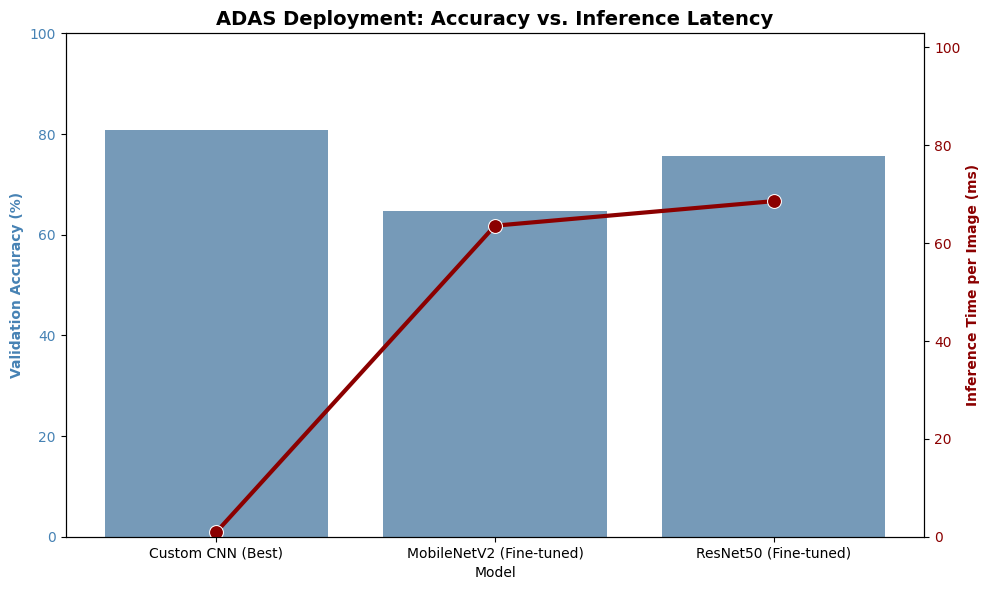

In [86]:
# 3. Dual-Axis Chart (Accuracy vs. Inference Time)
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar chart for Accuracy
sns.barplot(x='Model', y='Val_Accuracy (%)', data=df_tradeoff, ax=ax1, color='steelblue', alpha=0.8)
ax1.set_ylabel('Validation Accuracy (%)', color='steelblue', fontweight='bold')
ax1.set_ylim(0, 100)
ax1.tick_params(axis='y', labelcolor='steelblue')

# Line chart for Inference Time on secondary axis
ax2 = ax1.twinx()
sns.lineplot(x='Model', y='Inference_Time (ms)', data=df_tradeoff, ax=ax2, color='darkred', marker='o', linewidth=3, markersize=10)
ax2.set_ylabel('Inference Time per Image (ms)', color='darkred', fontweight='bold')
ax2.set_ylim(0, max(df_tradeoff['Inference_Time (ms)']) * 1.5)
ax2.tick_params(axis='y', labelcolor='darkred')

plt.title('ADAS Deployment: Accuracy vs. Inference Latency', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('tradeoff_analysis.png', dpi=150)
plt.show()


--- 8. FINAL MODEL EVALUATION ---

Evaluating on unseen Test Set...
395/395 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.8887 - loss: 0.4203

Final Test Accuracy: 88.89%
395/395 ━━━━━━━━━━━━━━━━━━━━ 16s 39ms/step

Classification Report:
                          precision    recall  f1-score   support

    Speed limit (20km/h)       0.81      0.22      0.34        60
    Speed limit (30km/h)       0.82      0.82      0.82       720
    Speed limit (50km/h)       0.97      0.98      0.98       660
    Speed limit (60km/h)       0.99      0.97      0.98       420
    Speed limit (70km/h)       0.99      0.94      0.97       690
    Speed limit (80km/h)       0.98      0.99      0.98       720
End speed limit (80km/h)       1.00      0.99      0.99       270
   Speed limit (100km/h)       0.97      0.98      0.98       210
   Speed limit (120km/h)       1.00      0.98      0.99       150
              No passing       1.00      0.85      0.92       360
     No passing veh>3.5t       0

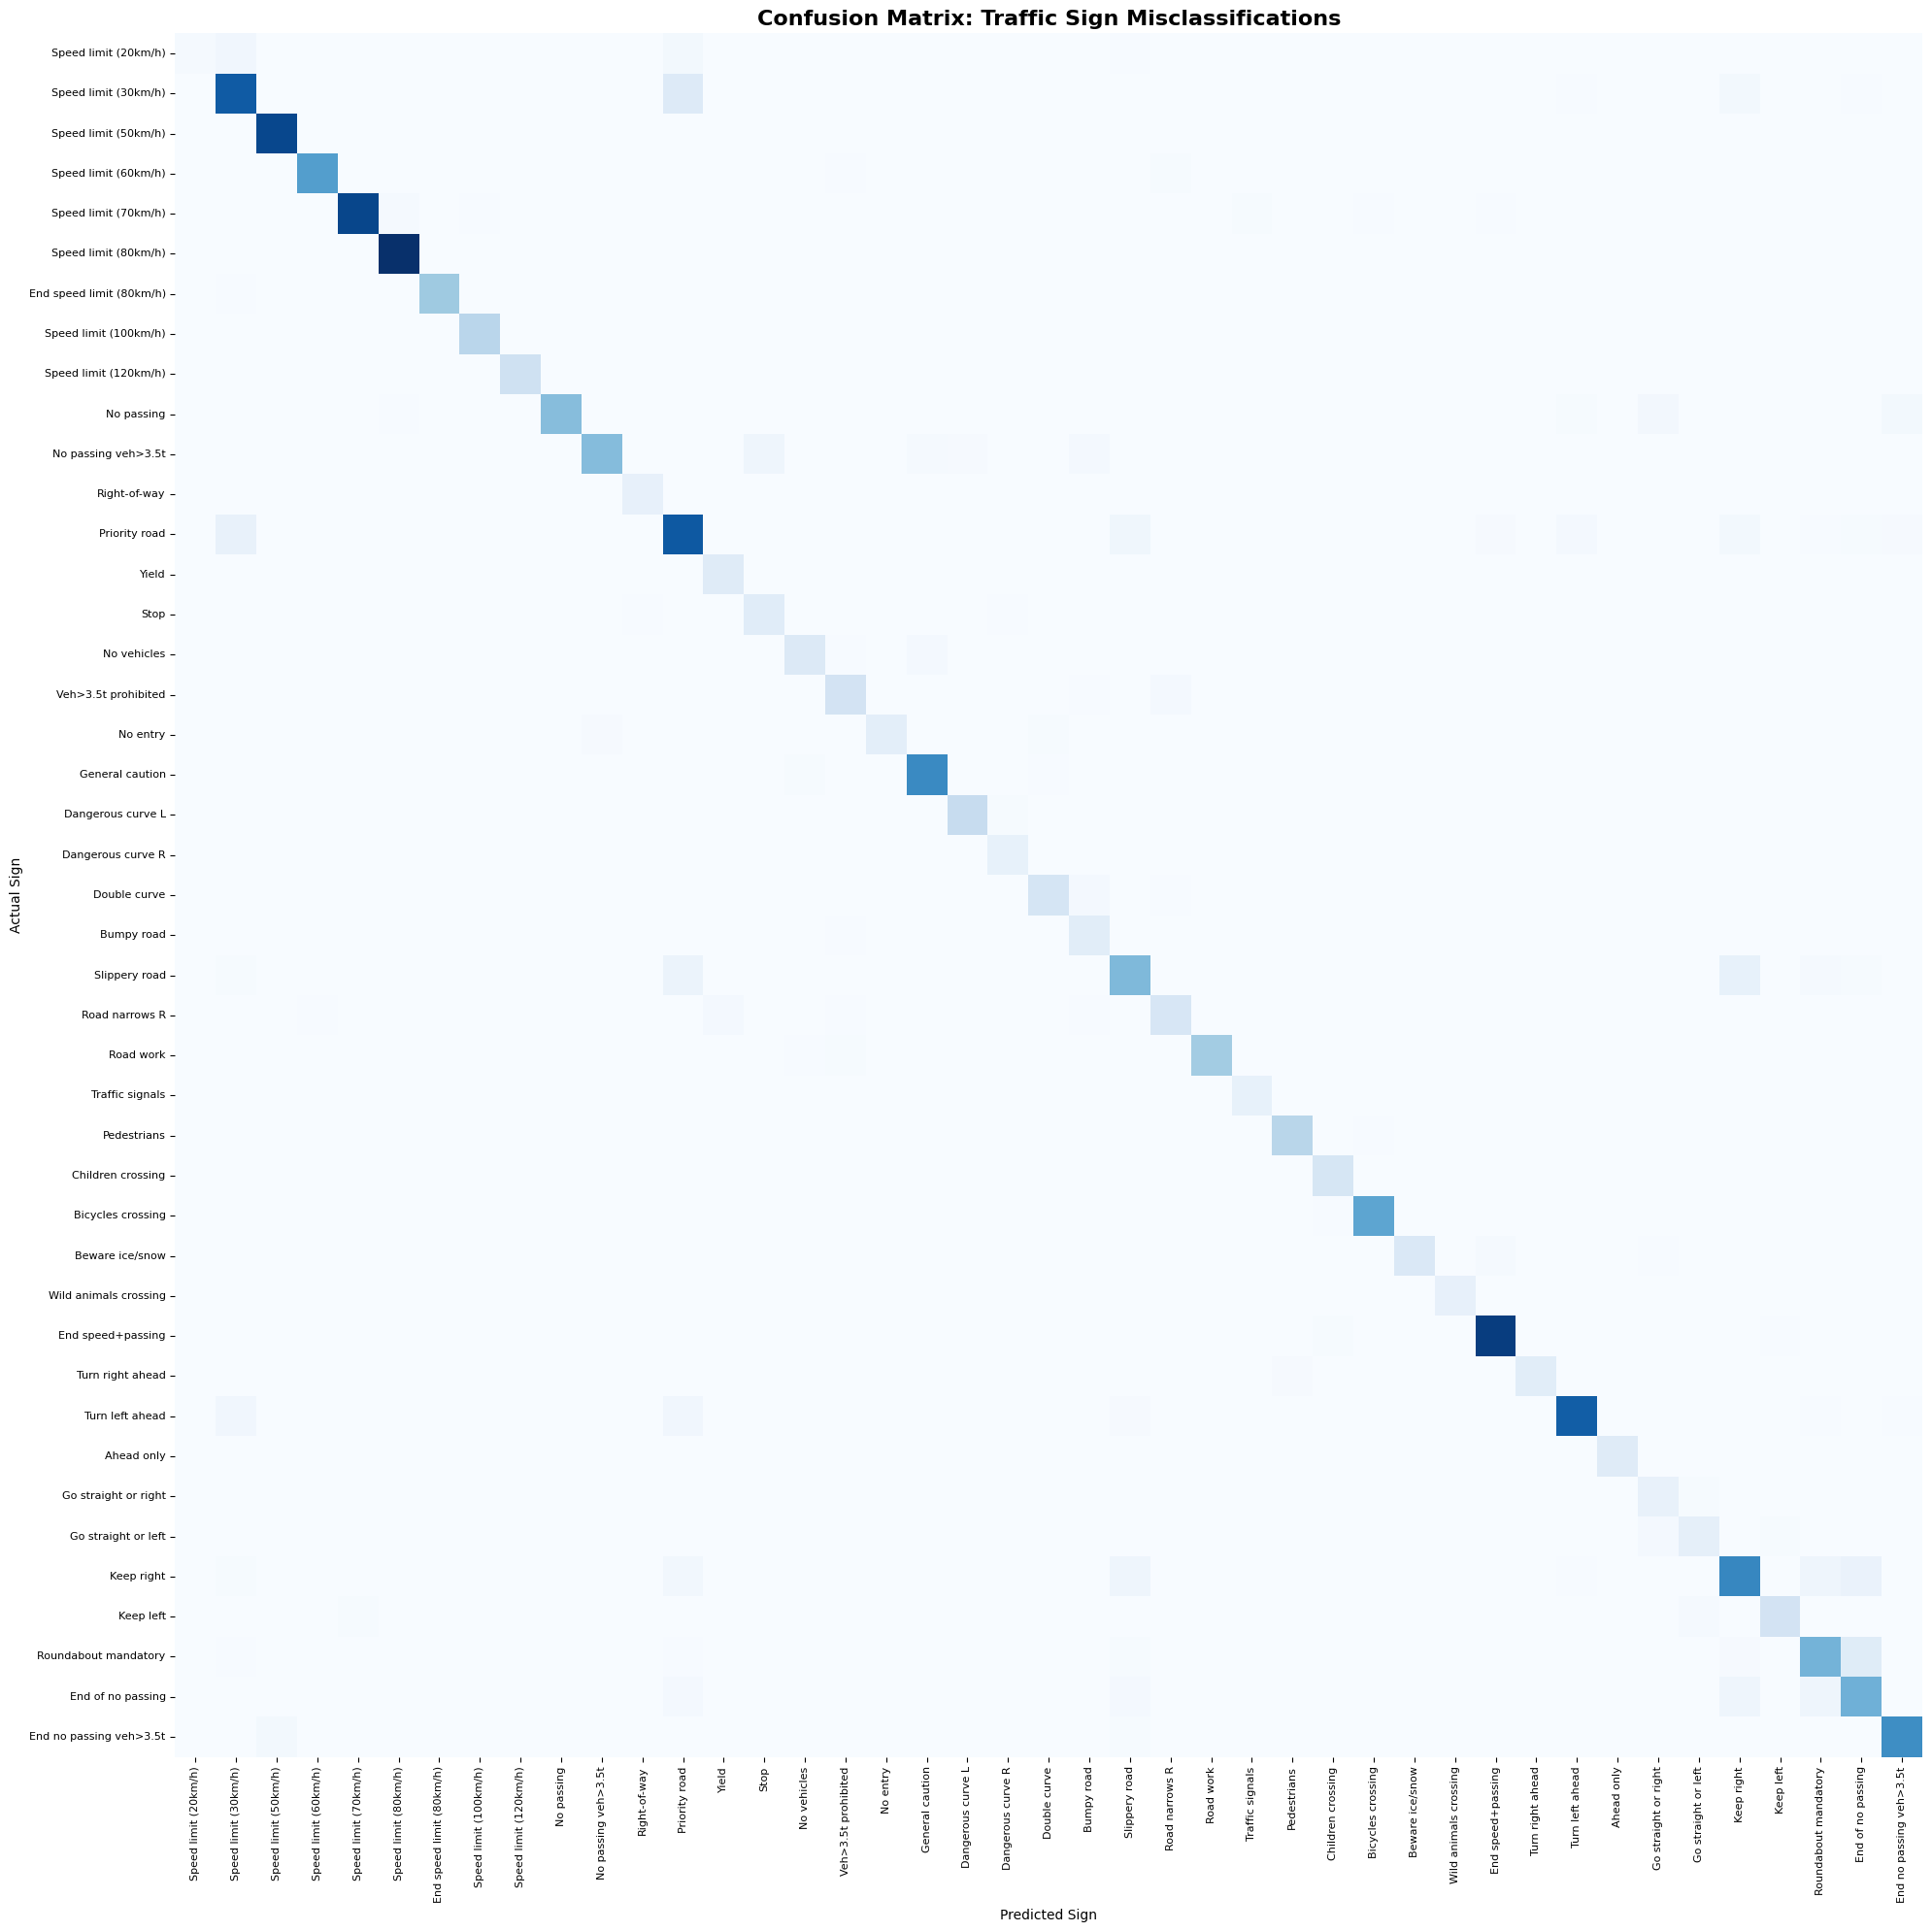


--- Visualizing Test Predictions ---


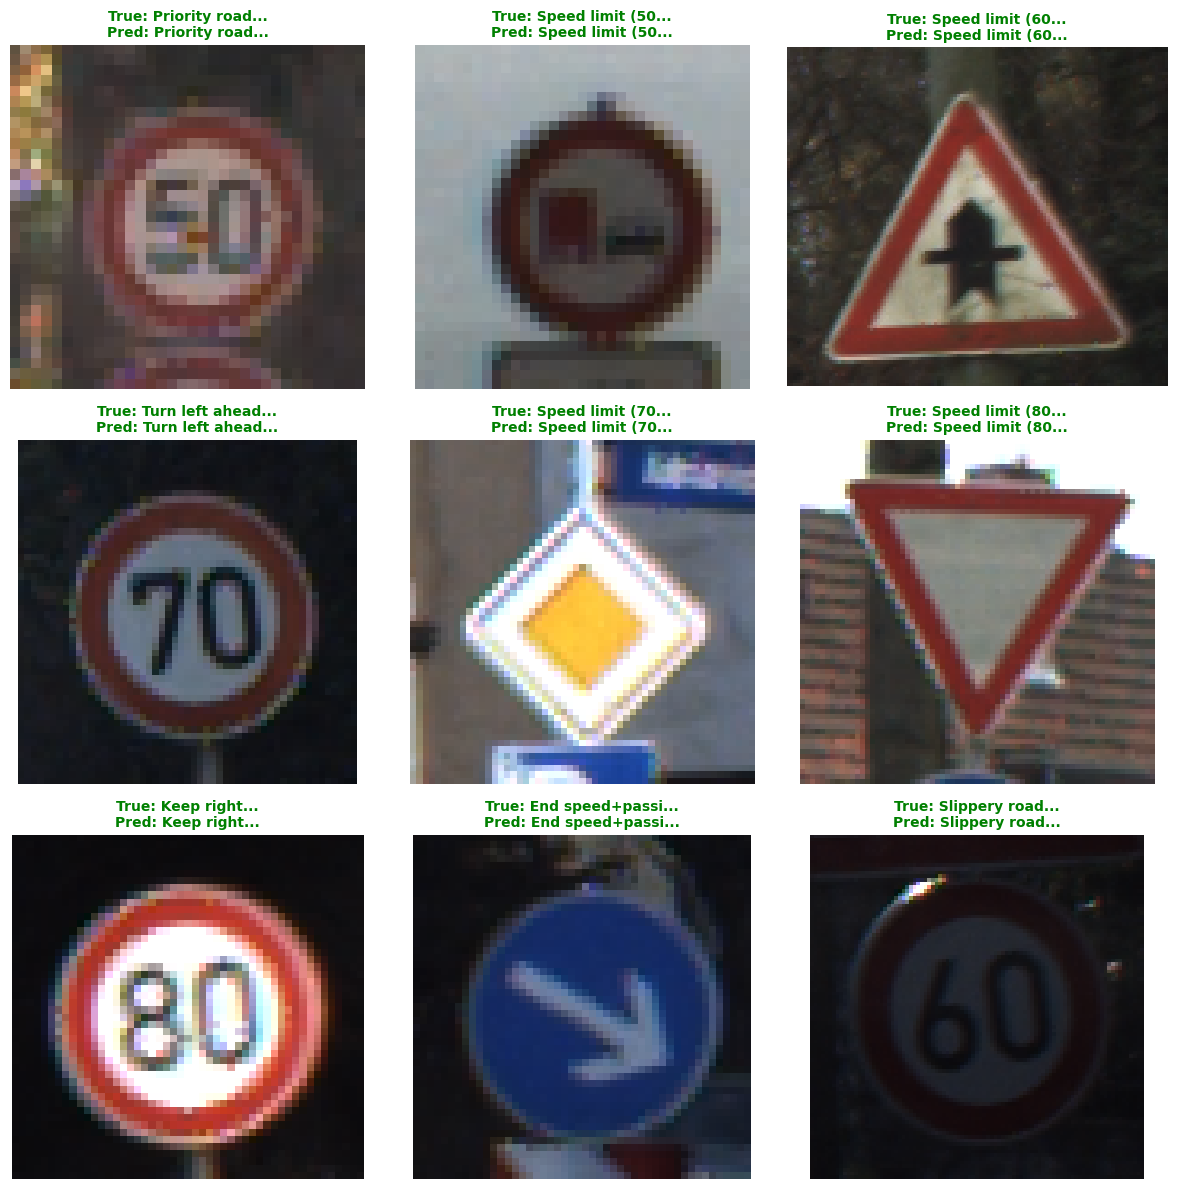

In [88]:
from sklearn.metrics import classification_report, confusion_matrix

print("--- 8. FINAL MODEL EVALUATION ---")

# We evaluate ResNet50 here since it achieved the highest accuracy in your run
final_model = custom_model

# 1. Evaluate on the Test Set
print("\nEvaluating on unseen Test Set...")
test_loss, test_acc = final_model.evaluate(test_gen, verbose=1)
print(f"\nFinal Test Accuracy: {test_acc*100:.2f}%")

# 2. Generate Predictions
test_gen.reset()
y_pred_probs = final_model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_gen.classes

# 3. Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=list(CLASS_NAMES.values())))

# 4. Confusion Matrix Heatmap
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(20, 20))
sns.heatmap(cm, annot=False, cmap='Blues', cbar=False, 
            xticklabels=list(CLASS_NAMES.values()), 
            yticklabels=list(CLASS_NAMES.values()))
plt.title('Confusion Matrix: Traffic Sign Misclassifications', fontsize=16, fontweight='bold')
plt.ylabel('Actual Sign')
plt.xlabel('Predicted Sign')
plt.xticks(rotation=90, fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# 5. Visual Grid of Predictions
print("\n--- Visualizing Test Predictions ---")
test_img_paths = test_gen.filepaths
np.random.seed(SEED)
sample_indices = np.random.choice(len(test_img_paths), 9, replace=False)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
for ax, idx in zip(axes.flat, sample_indices):
    img_path = test_img_paths[idx]
    true_label = y_true[idx]
    pred_label = y_pred[idx]
    
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    
    color = 'green' if true_label == pred_label else 'red'
    title = f"True: {CLASS_NAMES[true_label][:15]}...\nPred: {CLASS_NAMES[pred_label][:15]}..."
    ax.set_title(title, color=color, fontsize=10, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('prediction_grid.png', dpi=150)
plt.show()